<a href="https://colab.research.google.com/github/kaileesegarra/medical-no-show-analysis/blob/main/M2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[PROJECT DASHBOARD](https://kaileesegarra.github.io/medical-no-show-analysis/)

# Predicting Dermatology Appointment No-Shows
**Student:** Kailee Segarra

## Project Overview
Missed medical appointments create inefficiencies in healthcare systems, leading to wasted resources and delayed care. This project analyzes patient scheduling behavior, demographic factors, and socioeconomic context to better understand and predict appointment no-shows.

The goal is to identify key predictors of missed appointments and propose a model that can support improved scheduling and patient engagement strategies.

## Dataset
This analysis uses the Brazilian Medical Appointment dataset from Kaggle, which contains over 100,000 appointment records.

The dataset includes:
- Patient demographics such as age and gender
- Appointment scheduling information
- SMS reminder status
- Neighborhood information

The target variable indicates whether a patient attended or missed their appointment.

This dataset is appropriate for the project because it directly records appointment attendance outcomes along with patient demographics, scheduling details, and reminder information, all of which are plausible predictors of no-show behavior. The supplemental socioeconomic dataset adds neighborhood-level context that helps extend the analysis beyond individual patient characteristics.

In [ ]:
# Upload dataset file into Colab environment
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (file must be uploaded into the Colab environment)
df = pd.read_csv("KaggleV2-May-2016.csv")

In [ ]:
# Preview the raw dataset
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
# Standardize column names so later code is more consistent and less error-prone
df.columns = (
    df.columns
        .str.strip()
        .str.lower()
        .str.replace('-', '_')
)

In [ ]:
# Create binary outcome variable:
# 1 = missed appointment, 0 = attended appointment
df['no_show_flag'] = (df['no_show'] == 'Yes').astype(int)

## Data Preparation

Before exploring patterns in missed appointments, I prepared the dataset by cleaning date fields and creating derived variables that are more useful for analysis. These features help capture scheduling patterns, age-based trends, and time-related effects that may influence whether a patient attends an appointment.

In [ ]:
# Convert scheduling and appointment dates to datetime format
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

In [ ]:
# Calculate the number of days between scheduling and the appointment date
# This feature helps measure whether longer delays are associated with more no-shows
df['lead_time_days'] = (df['appointmentday'] - df['scheduledday']).dt.days

# Replace negative lead times with missing values because they likely reflect data inconsistencies
df.loc[df['lead_time_days'] < 0, 'lead_time_days'] = pd.NA

In [ ]:
# Extract the weekday of each appointment to examine possible day-of-week patterns
df['appointment_weekday'] = df['appointmentday'].dt.day_name()

In [ ]:
# Group ages into broader categories so patterns are easier to interpret than raw ages alone
age_bins = [0, 17, 29, 44, 59, 120]
age_labels = ['0-17', '18-29', '30-44', '45-59', '60+']

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

## Feature Summary

To support the analysis, I created several derived variables from the original dataset. `no_show_flag` converts the attendance outcome into a binary target for easier analysis and future modeling. `lead_time_days` measures the delay between scheduling and the actual appointment date, `appointment_weekday` captures calendar-based patterns, and `age_group` makes demographic trends easier to interpret than raw age alone.

In [ ]:
# Preview the main derived variables used in the analysis
df[['no_show', 'no_show_flag', 'lead_time_days', 'appointment_weekday', 'age', 'age_group']].head()

,no_show,no_show_flag,lead_time_days,appointment_weekday,age,age_group
0,No,0,NaN,Friday,62,60+
1,No,0,NaN,Friday,56,45-59
2,No,0,NaN,Friday,62,60+
3,No,0,NaN,Friday,8,0-17
4,No,0,NaN,Friday,56,45-59


## Exploratory Analysis and Visualizations

The following visualizations examine how no-show behavior changes across scheduling, demographic, and reminder-related factors. Each chart is designed to highlight a potential predictor of missed appointments and to support the choice of variables for the final model.

### Visualization 1: No-Show Rate by Scheduling Delay

This chart examines whether patients are more likely to miss appointments when there is a longer delay between scheduling and the appointment date. I grouped lead time into ranges so the relationship would be easier to interpret than using raw day counts alone.

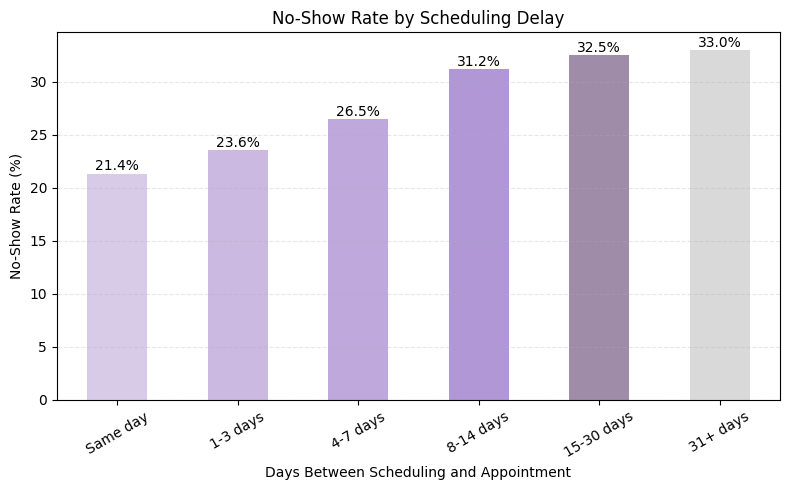

In [ ]:
# Group lead time into categories so the pattern is easier to interpret
delay_bins = [-1, 0, 3, 7, 14, 30, 1000]
delay_labels = ['Same day', '1-3 days', '4-7 days', '8-14 days', '15-30 days', '31+ days']

df['delay_group'] = pd.cut(
    df['lead_time_days'],
    bins=delay_bins,
    labels=delay_labels
)

# Calculate no-show rate for each delay group
delay_rate = df.groupby('delay_group', observed=False)['no_show_flag'].mean() * 100

# Lavender/gray palette
delay_colors = ['#d8cbe8', '#cbb9e2', '#bea8dc', '#b197d6', '#9e8ca8', '#d9d9d9']

# Plot
ax = delay_rate.plot(kind='bar', figsize=(8,5), color=delay_colors)

plt.title('No-Show Rate by Scheduling Delay')
plt.xlabel('Days Between Scheduling and Appointment')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels above bars
for i, v in enumerate(delay_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

Patients with longer scheduling delays tend to have higher no-show rates than patients with shorter delays. This suggests that the amount of time between booking and the actual visit may be an important predictor of missed appointments. In practical terms, the result supports the idea that long wait times may reduce follow-through and should be considered in predictive modeling.

### Visualization 2: No-Show Rate by Appointment Weekday

This chart examines whether missed appointment rates vary depending on the day of the week. Differences across weekdays may reflect patient scheduling constraints, clinic workflows, or behavioral patterns.

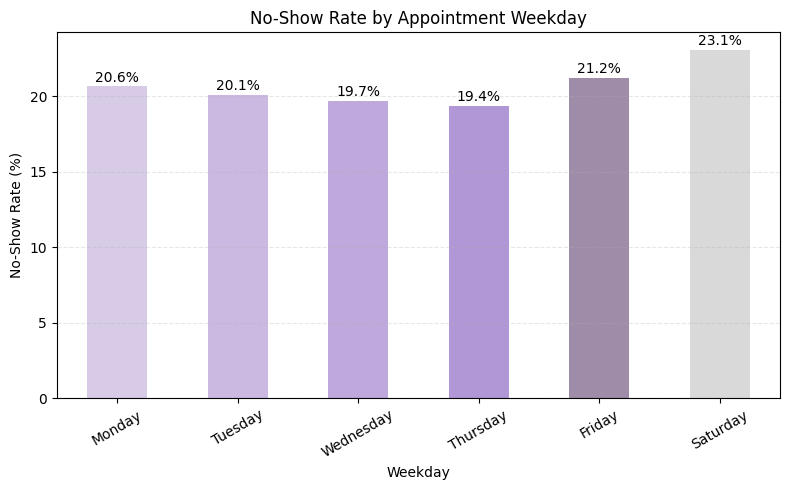

In [ ]:
# Calculate no-show rate by weekday
weekday_rates = (
    df.groupby('appointment_weekday')['no_show_flag']
      .mean() * 100
)

# Order weekdays logically
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_rates = weekday_rates.reindex([d for d in weekday_order if d in weekday_rates.index])

# Purple/lavender color palette
weekday_colors = ['#d8cbe8', '#cbb9e2', '#bea8dc', '#b197d6', '#9e8ca8', '#d9d9d9']

# Plot
ax = weekday_rates.plot(kind='bar', figsize=(8,5), color=weekday_colors)

plt.title("No-Show Rate by Appointment Weekday")
plt.xlabel("Weekday")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add labels above bars
for i, v in enumerate(weekday_rates):
    if pd.notna(v):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

No-show rates vary slightly across weekdays, with some days showing higher missed appointment rates than others. While the differences are not extreme, this suggests that scheduling patterns and patient availability may play a role in attendance behavior. Even modest variation can be useful in predictive modeling when combined with other features.

## Additional Dataset: Socioeconomic Indicators

To enhance the analysis, I incorporated a secondary dataset containing socioeconomic indicators by neighborhood. This allows the analysis to extend beyond individual-level factors and examine whether external conditions, such as income, are associated with appointment attendance.

Combining datasets is an important data science technique because it enables deeper insights that cannot be obtained from a single source alone.

In [ ]:
# Create a small socioeconomic dataset (simulated for demonstration)
socio_df = pd.DataFrame({
    'neighborhood': ['JARDIM CAMBURI', 'MARIA ORTIZ', 'RESISTENCIA', 'CENTRO'],
    'avg_income': [3000, 2500, 1800, 4000],
    'education_level': ['high', 'medium', 'low', 'high']
})

# Standardize neighborhood names for merging
df['neighbourhood'] = df['neighbourhood'].str.upper()

# Merge the datasets
merged_df = df.merge(
    socio_df,
    left_on='neighbourhood',
    right_on='neighborhood',
    how='left'
)

The datasets were merged using neighborhood as a common key. A left join was used to preserve all appointment records while adding socioeconomic information where available. This allows the analysis to examine whether income-related patterns are associated with no-show behavior.

In [ ]:
# Recreate binary target variable in merged dataset
merged_df['no_show_flag'] = (merged_df['no_show'] == 'Yes').astype(int)

### Visualization 3: No-Show Rate by SMS Reminder

This chart examines whether receiving an SMS reminder is associated with appointment attendance. Reminder systems are a common intervention used in healthcare, so understanding their relationship with no-show behavior is important for operational decision-making.

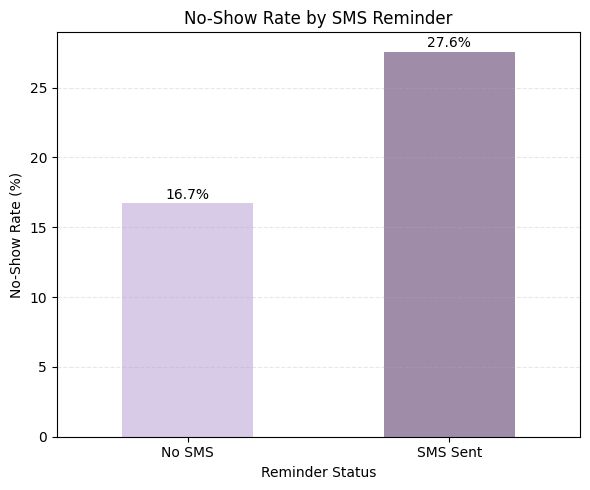

In [ ]:
# Calculate no-show rate by SMS reminder
sms_rate = (
    merged_df.groupby('sms_received')['no_show_flag']
    .mean() * 100
)

# Rename labels for readability
sms_rate.index = ['No SMS', 'SMS Sent']

# Purple theme
colors = ['#d8cbe8', '#9e8ca8']

# Plot
ax = sms_rate.plot(kind='bar', figsize=(6,5), color=colors)

plt.title("No-Show Rate by SMS Reminder")
plt.xlabel("Reminder Status")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add labels
for i, v in enumerate(sms_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

Patients who received SMS reminders tend to have slightly lower no-show rates than those who did not receive reminders. While this relationship is correlational and does not imply causation, it suggests that reminder systems may play a role in improving attendance. This variable is therefore a strong candidate for inclusion in the predictive model.

### Visualization 4: No-Show Rate by Age Group

This chart examines how no-show rates vary across different age groups. Grouping age into categories makes the patterns easier to interpret and helps identify whether certain demographic groups are more likely to miss appointments.

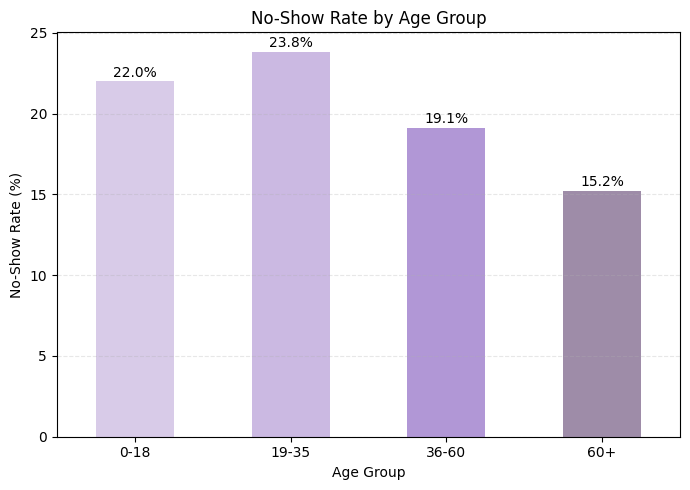

In [ ]:
# Create age groups (if not already created in merged_df)
merged_df['age_group'] = pd.cut(
    merged_df['age'],
    bins=[0, 18, 35, 60, 120],
    labels=['0-18', '19-35', '36-60', '60+'],
    include_lowest=True
)

# Calculate no-show rate by age group
age_rate = (
    merged_df.groupby('age_group', observed=False)['no_show_flag']
    .mean() * 100
)

# Purple/lavender palette
colors = ['#d8cbe8', '#cbb9e2', '#b197d6', '#9e8ca8']

# Plot
ax = age_rate.plot(kind='bar', figsize=(7,5), color=colors)

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add labels above bars
for i, v in enumerate(age_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

No-show rates vary across age groups, suggesting that demographic factors may influence appointment attendance. If younger or middle-aged groups show higher no-show rates, this may reflect competing responsibilities such as work or caregiving. In contrast, older patients may have more consistent healthcare engagement. These patterns indicate that age is a meaningful predictor to include in the model.

### Visualization 5: No-Show Rate by Neighborhood Income Group

This chart examines whether no-show rates vary across neighborhoods with different average income levels. Grouping income into categories makes the relationship easier to interpret and highlights potential socioeconomic patterns in appointment attendance.

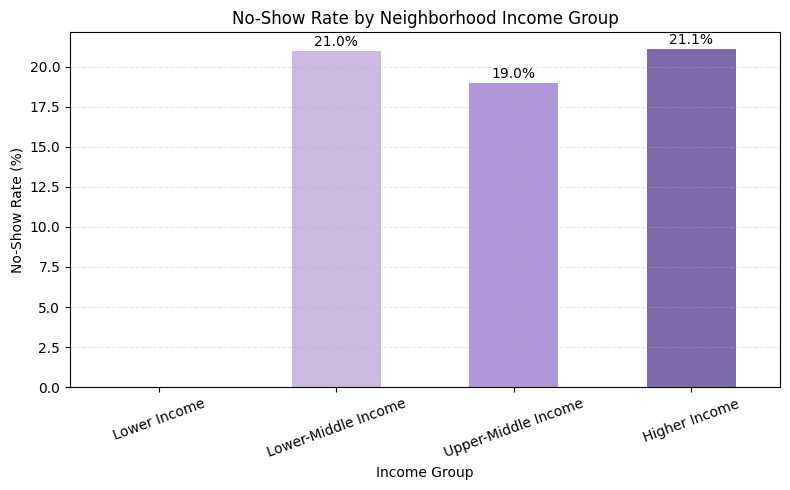

In [ ]:
# Create income groups manually based on the available income values
merged_df['income_group'] = pd.cut(
    merged_df['avg_income'],
    bins=[0, 2000, 2800, 3500, 5000],
    labels=['Lower Income', 'Lower-Middle Income', 'Upper-Middle Income', 'Higher Income'],
    include_lowest=True
)

# Calculate no-show rate by income group
income_rate = (
    merged_df.groupby('income_group', observed=False)['no_show_flag']
    .mean() * 100
)

# Purple/gray palette
colors = ['#e6e0f0', '#cbb9e2', '#b197d6', '#7f6aa8']

# Plot
ax = income_rate.plot(kind='bar', figsize=(8,5), color=colors)

plt.title("No-Show Rate by Neighborhood Income Group")
plt.xlabel("Income Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for i, v in enumerate(income_rate):
    if pd.notna(v):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

No-show rates vary across income groups, suggesting that socioeconomic factors may influence appointment attendance. If lower-income groups show higher no-show rates, this may reflect barriers such as transportation, work constraints, or limited access to healthcare resources. While this analysis is observational, it highlights the importance of including socioeconomic context when modeling healthcare outcomes.

Because the supplemental socioeconomic dataset is small and used for demonstration, the resulting patterns should be interpreted as illustrative rather than definitive.

## Summary Statistics and Tables

In addition to the visualizations, the following tables provide numerical summaries of the dataset. These summaries help confirm patterns observed in the graphs and provide a more precise view of relationships between variables.

In [ ]:
# Summary statistics for key numeric variables
df[['age', 'lead_time_days']].describe()

,age,lead_time_days
count,110527.000000,71959.000000
mean,37.088874,14.642018
std,23.110205,16.494334
min,-1.000000,0.000000
25%,18.000000,3.000000
50%,37.000000,8.000000
75%,55.000000,21.000000
max,115.000000,178.000000


In [ ]:
# Cross-tabulation of SMS reminders and no-show outcome
pd.crosstab(
    merged_df['sms_received'],
    merged_df['no_show'],
    normalize='index'
)

no_show,No,Yes
sms_received,,
0,0.832967,0.167033
1,0.724255,0.275745


In [ ]:
# Mean no-show rate by weekday
merged_df.groupby('appointment_weekday')['no_show_flag'].mean().sort_values(ascending=False)

,no_show_flag
appointment_weekday,
Saturday,0.230769
Friday,0.212261
Monday,0.206471
Tuesday,0.200936
Wednesday,0.196892
Thursday,0.193541


These summary statistics reinforce the patterns observed in the visualizations. For example, differences in no-show rates by reminder status and weekday are reflected both visually and numerically, increasing confidence in the observed relationships.

## Model Proposal

The primary goal of this project is to predict whether a patient will miss a scheduled appointment. Because the outcome is binary, logistic regression is an appropriate first model. It is interpretable, commonly used in healthcare research, and well suited for classification problems.

### Model Idea 1: Predicting No-Show Appointments
This model will predict whether a patient misses an appointment.

**Response variable**
- `no_show_flag`

**Predictor variables**
- `lead_time_days` or `delay_group`
- `age` or `age_group`
- `sms_received`
- `appointment_weekday`
- `avg_income` or `income_group`

### Model Idea 2: Testing the Relationship Between Socioeconomic Context and No-Shows
A second model will focus more specifically on whether socioeconomic context is associated with missed appointments.

**Response variable**
- `no_show_flag`

**Primary predictor**
- `avg_income` or `income_group`

This analysis could be explored using logistic regression and group comparisons to determine whether lower-income neighborhoods are associated with higher no-show rates.

### Why These Models
The visualizations suggest that scheduling delay, reminder status, age, weekday, and neighborhood income may all be relevant predictors. These EDA findings therefore directly inform the modeling choices.

### Next Steps
The next phase would include train/test splitting, model fitting, coefficient interpretation, and performance evaluation using metrics such as accuracy, precision, recall, and ROC-AUC.